In [99]:
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer


In [100]:
df = pd.read_csv('concrete_data.csv')

In [101]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [102]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [103]:
x= df.drop('Strength',axis=1)
y = df['Strength']

In [104]:
x_train,x_test , y_train , y_test = train_test_split(x , y,test_size=0.2,random_state=42)

In [105]:
lr = LinearRegression()

In [106]:
lr.fit(x_train , y_train)

LinearRegression()

In [107]:
y_pred = lr.predict(x_test)

In [108]:
print(r2_score(y_test , y_pred))

0.627553179231485


In [109]:
print(np.mean(cross_val_score(lr , df.iloc[ : , : 8] , df.iloc[: , 8:] , scoring= "r2" ,  cv=5)))

0.46099404916628606


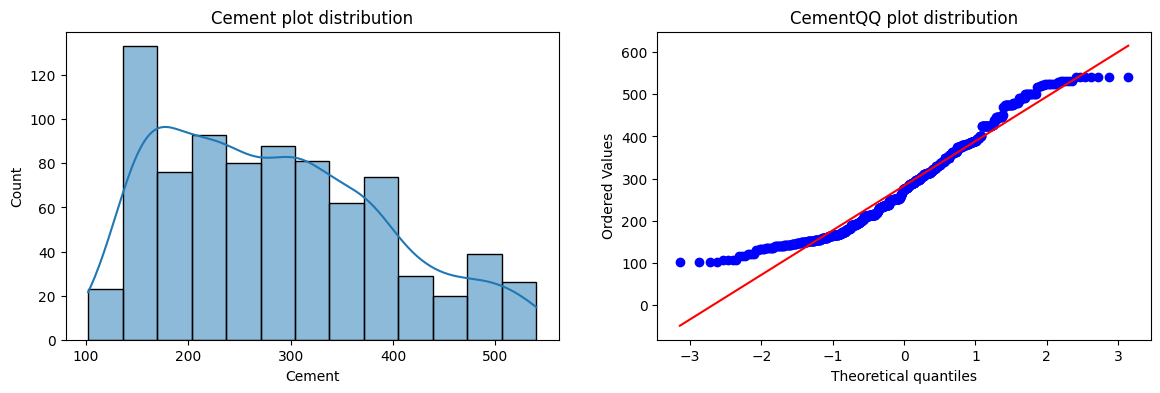

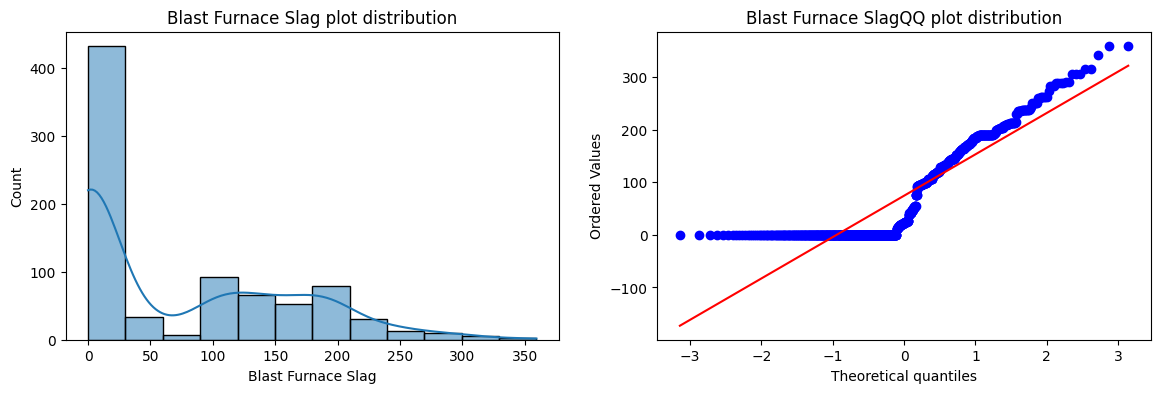

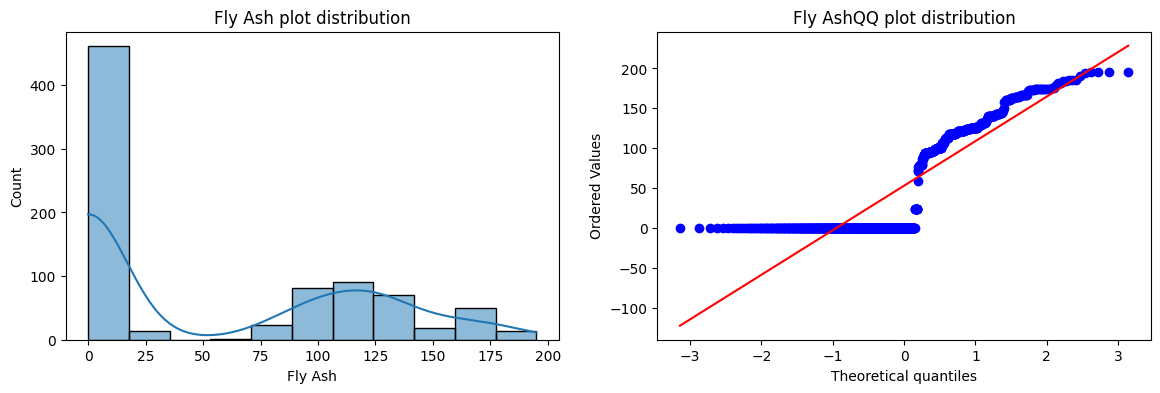

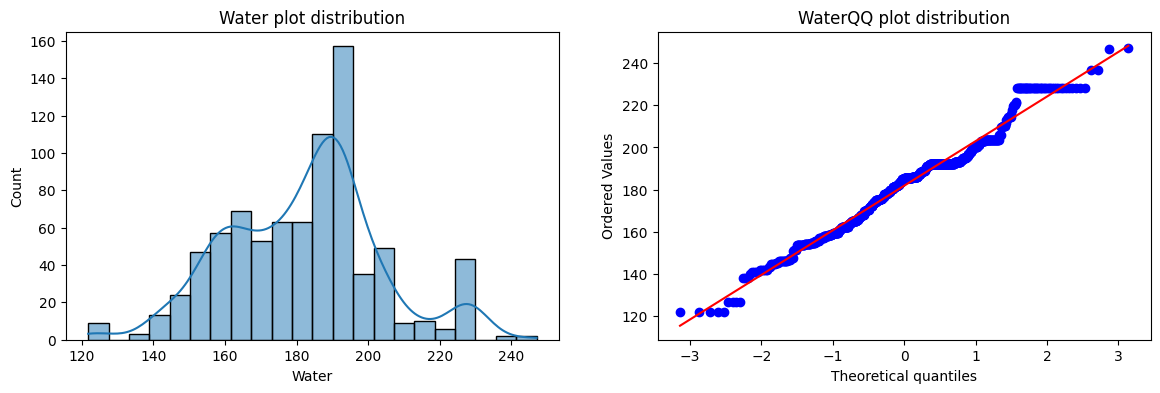

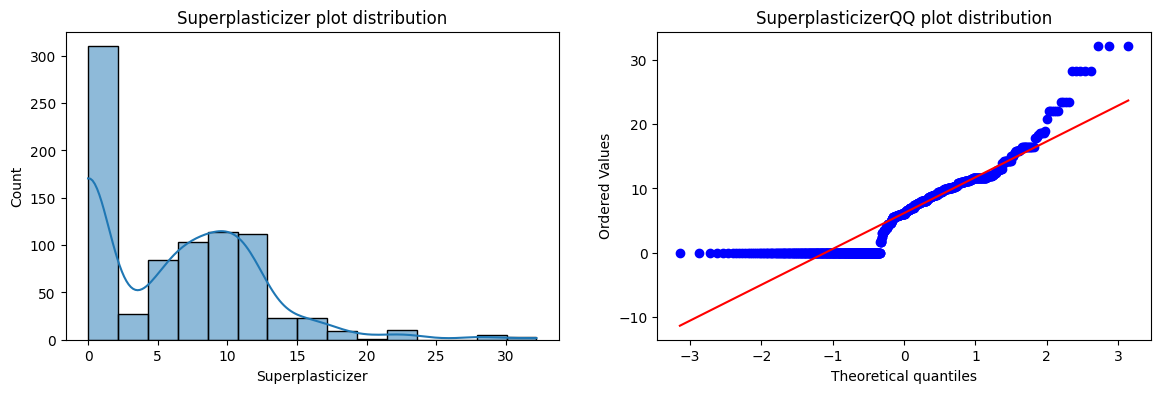

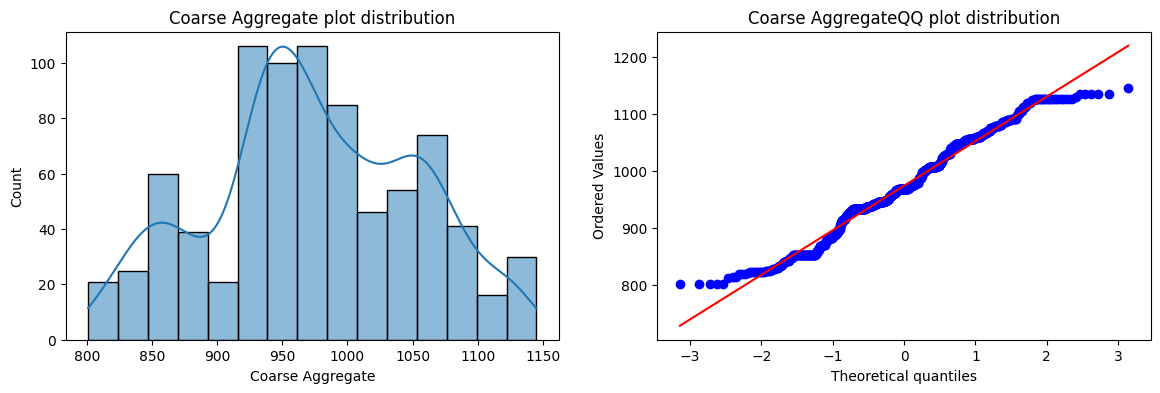

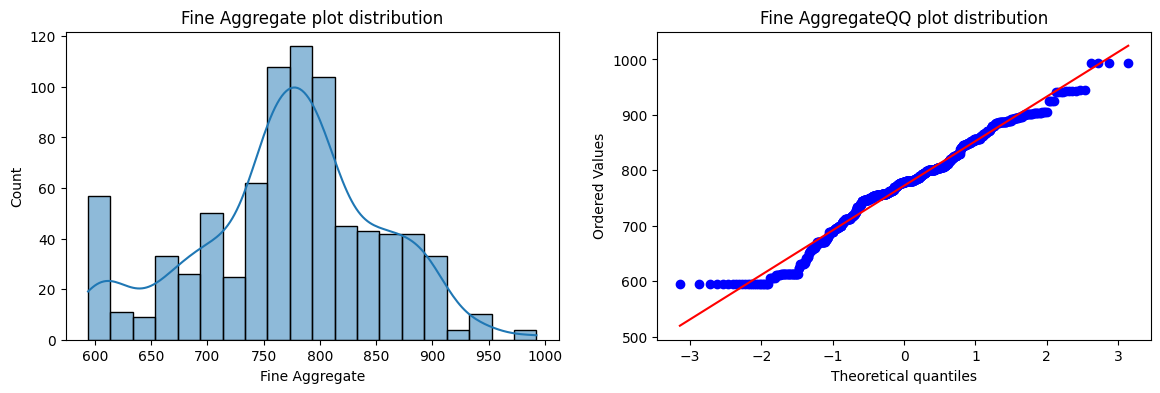

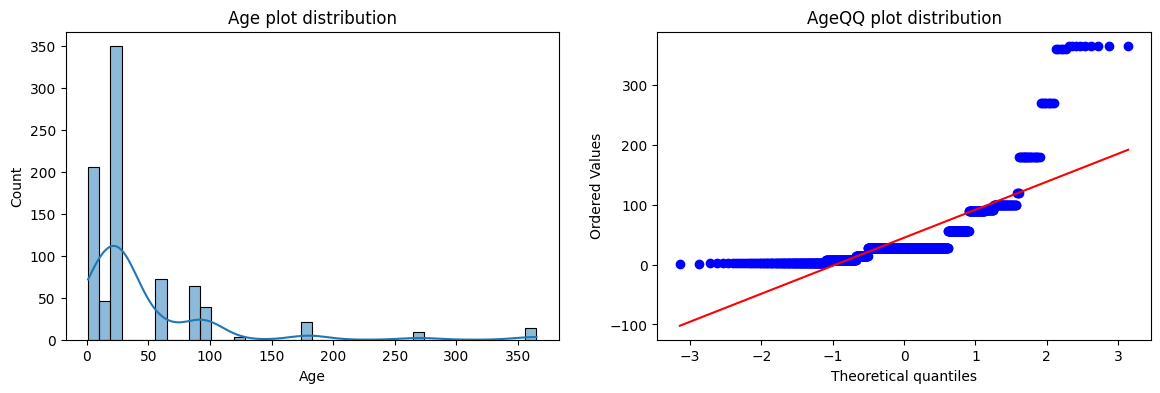

In [110]:
for col in x_train.columns :
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(x_train[col] , kde=True )
  plt.title(f"{col} plot distribution")

  plt.subplot(122)
  stats.probplot(x_train[col] , dist="norm" , plot= plt)
  plt.title(f"{col}QQ plot distribution")
  plt.show()

In [113]:
pt = PowerTransformer(method="box-cox")

In [114]:
x_train_trf1 = pt.fit_transform(x_train + 0.000001)
x_test_trf1 = pt.transform(x_test + 0.000001 )

In [115]:
clf1 = LinearRegression()

In [116]:
clf1.fit(x_train_trf1 , y_train)

LinearRegression()

In [117]:
y_pred = clf1.predict(x_test_trf1)

In [118]:
print(r2_score(y_test, y_pred))

0.8047824993092503


In [119]:
print(np.mean(cross_val_score(clf1 , x_train_trf1 , y_train ,   scoring="r2" ,  cv=5)))

0.7923976598693296


In [120]:
x_train_trf1 = pd.DataFrame(x_train_trf1,columns=x_train.columns)
x_test_trf1 = pd.DataFrame(x_test_trf1,columns=x_test.columns)

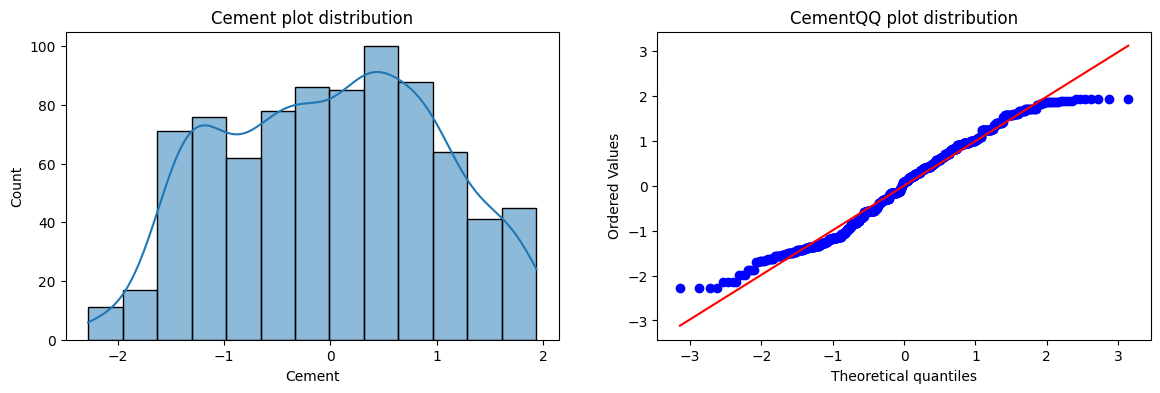

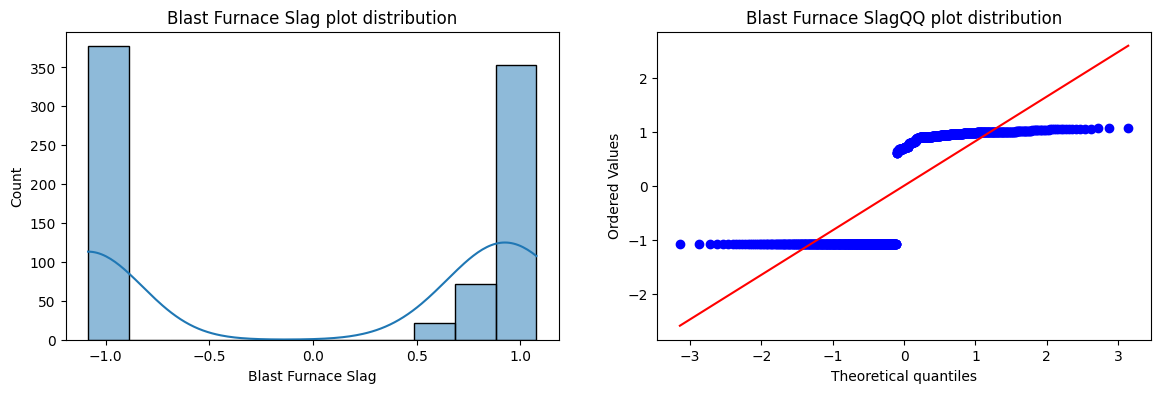

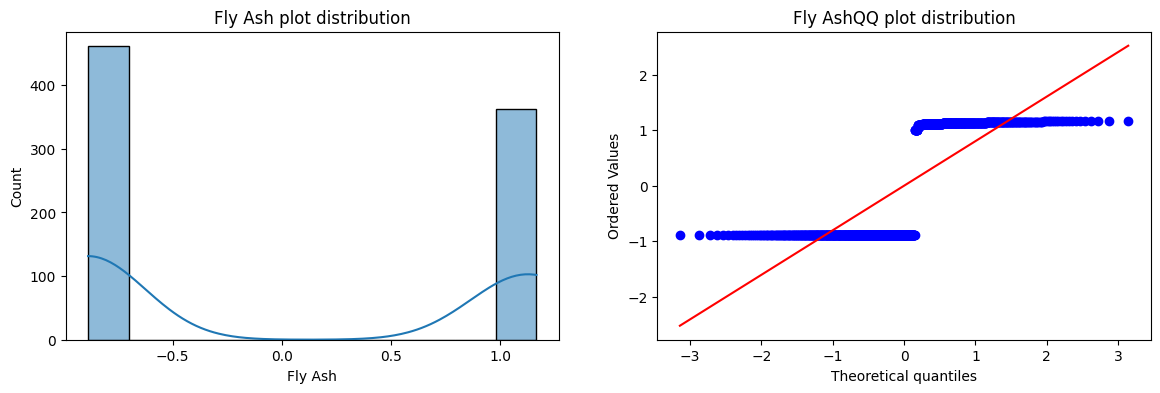

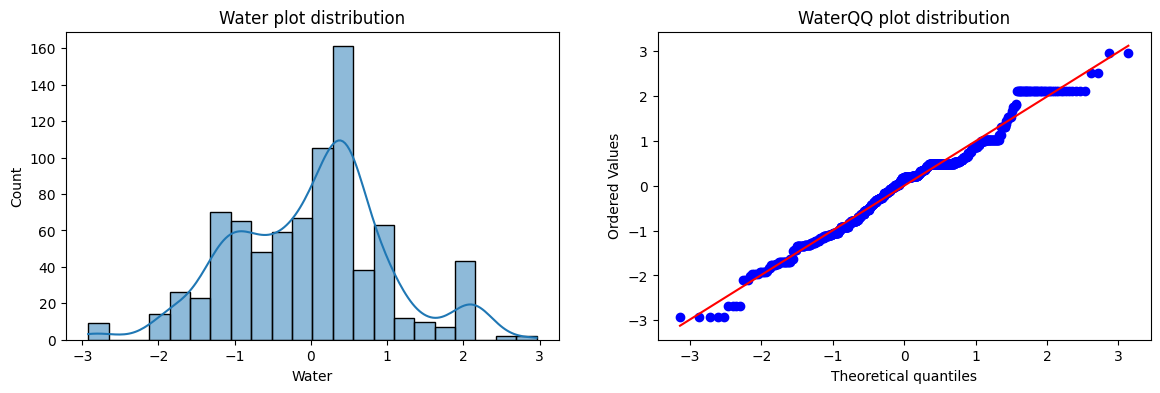

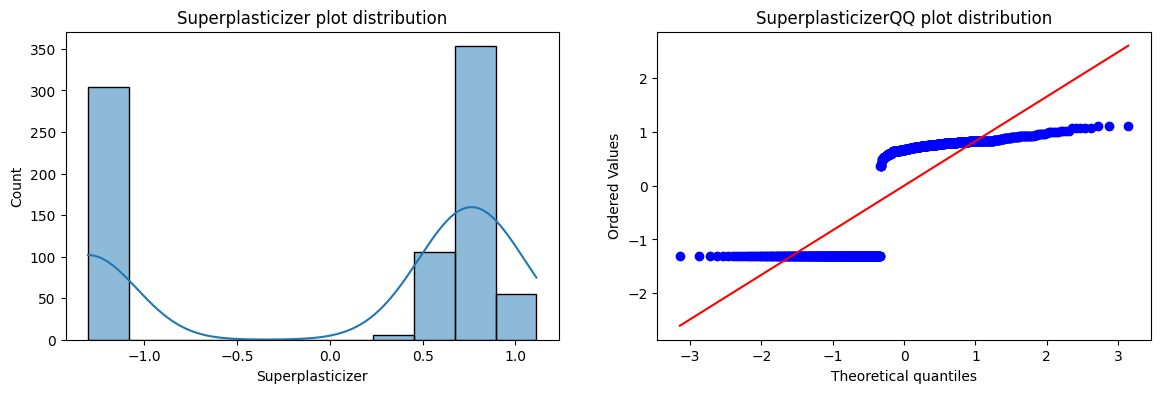

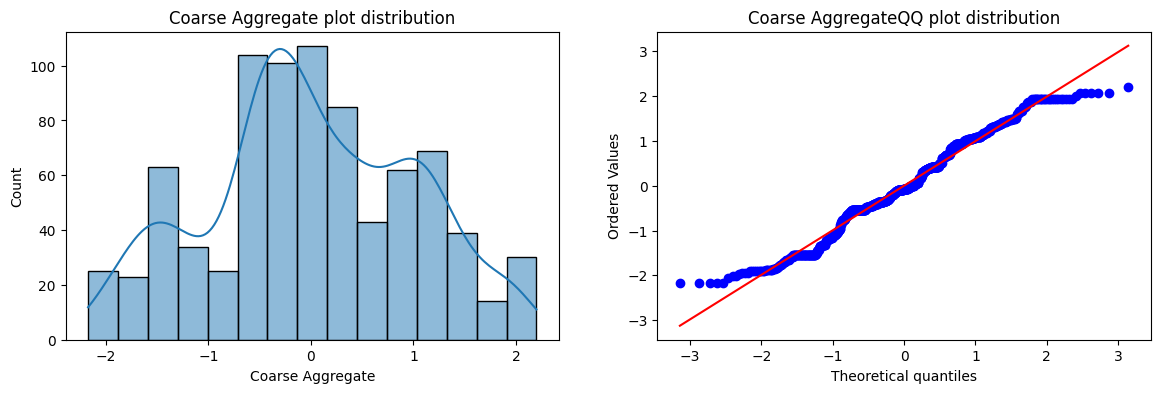

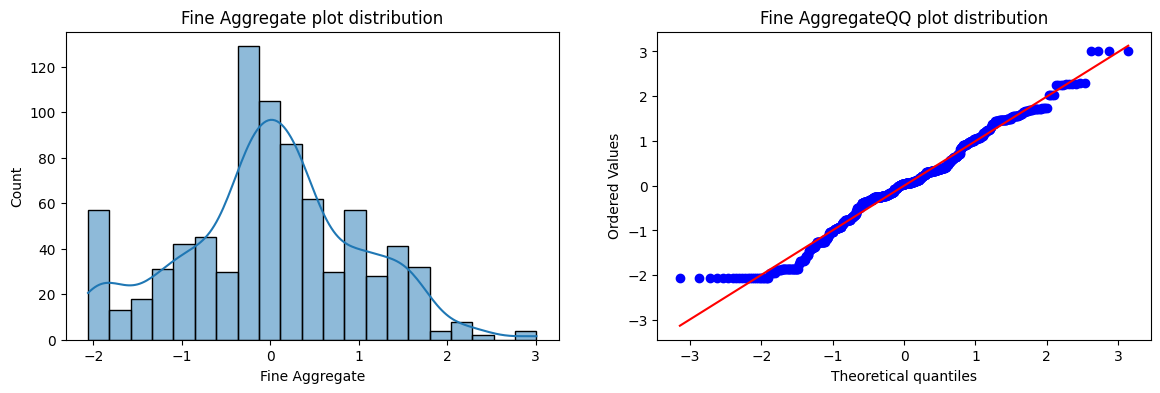

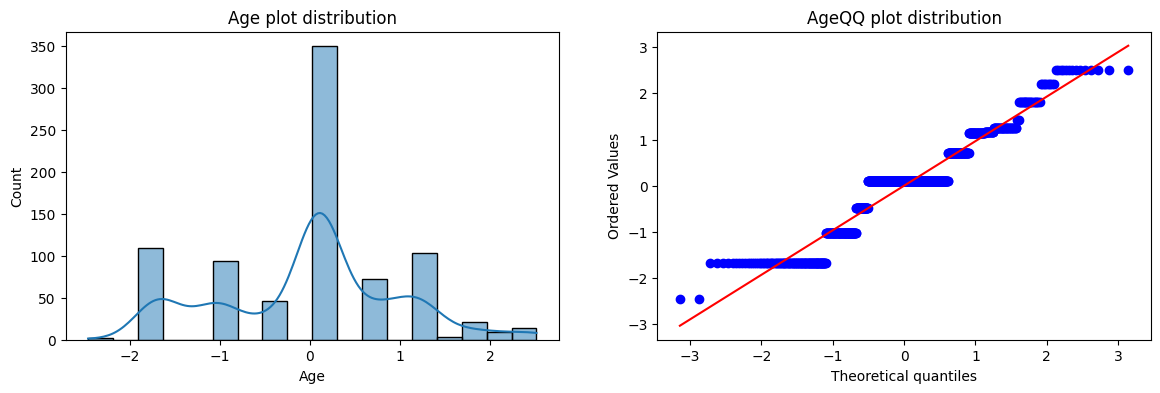

In [121]:
for col in x_train_trf1.columns :
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(x_train_trf1[col] , kde=True )
  plt.title(f"{col} plot distribution")

  plt.subplot(122)
  stats.probplot(x_train_trf1[col] , dist="norm" , plot= plt)
  plt.title(f"{col}QQ plot distribution")
  plt.show()